In [1]:
import kagglehub

In [2]:
local_dataset_path = kagglehub.dataset_download('irkaal/foodcom-recipes-and-reviews')

In [3]:
import pandas as pd
import matplotlib.pyplot as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import os
full_reviews_path = os.path.join(local_dataset_path, 'reviews.csv')
reviews = pd.read_csv(full_reviews_path)

In [5]:
!pip install gdown

# ID del archivo de Google Drive
file_id = '1Rl8XowC9N6cxrdiPvH4wToFUvZrrBqRG'
output_filename = 'recipes_final_consolidado.csv'

# Descargar el archivo usando gdown
!gdown --id {file_id} -O {output_filename}

# Cargar el archivo CSV con pandas
recipes = pd.read_csv(output_filename)
recipes['ExtractedServingSize'] = recipes['ExtractedServingSize'].str.extract(r'\((.*?)\)').astype(float)


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\Hanibal Villegas\AppData\Local\Programs\Python\Python310\lib\site-packages\gdown\__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1Rl8XowC9N6cxrdiPvH4wToFUvZrrBqRG
From (redirected): https://drive.google.com/uc?id=1Rl8XowC9N6cxrdiPvH4wToFUvZrrBqRG&confirm=t&uuid=2faa4656-80b8-4281-b355-b704be167c8a
To: c:\Users\Hanibal Villegas\OneDrive\Escritorio\Implementaciones_ejecutadas_paper\recipes_final_consolidado.csv

  0%|          | 0.00/713M [00:00<?, ?B/s]
  0%|          | 3.15M/713M [00:00<00:25, 28.1MB/s]
  1%|          | 6.82M/713M [00:00<00:22, 31.5MB/s]
  1%|▏         | 10.5M/713M [00:00<00:21, 32.1MB/s]
  2%|▏         | 14.2M/713M [00:00<00:20, 33.8MB/s]
  2%|▏   

In [6]:
# Filtrar la receta con ExtractedServingSize igual a -475.0
receta_anomala = recipes[recipes['ExtractedServingSize'] == -475.0]
display(receta_anomala)

,RecipeId,Name,AuthorId,AuthorName,CookTime,PrepTime,TotalTime,DatePublished,Description,Images,...,FiberContent,SugarContent,ProteinContent,RecipeServings,RecipeYield,RecipeInstructions,ExtractedServingSize,ExtractedServings,ExtractedServings_clean,ConsolidatedServings
16628,19962,Rainforest Cafe Rasta Pasta for Two or Three,10404,Diana Adcock,PT15M,PT5M,PT20M,2002-02-18T09:24:00Z,Make and share this Rainforest Cafe Rasta Past...,"""https://img.sndimg.com/food/image/upload/w_55...",...,7.2,4.8,19.7,2.0,NaN,"c(""Cook pasta according to package directions....",-475.0,2,2,2


In [7]:
def get_stats(recipes, reviews):
  num_users = reviews['AuthorId'].nunique()
  num_items = recipes['RecipeId'].nunique()
  total_ratings = len(reviews)
  avg_ratings_per_user = total_ratings / num_users
  avg_ratings_per_item = total_ratings / num_items
  avg_rating = reviews['Rating'].mean()
  mode_rating = reviews['Rating'].mode()[0]
  std_rating = reviews['Rating'].std()
  highest_ratings_user = reviews.groupby('AuthorId')['Rating'].count().max()
  highest_ratings_item = reviews.groupby('RecipeId')['Rating'].count().max()
  density = (total_ratings / (num_users * num_items)) * 100
  return [
      num_users,
      num_items,
      total_ratings,
      round(avg_ratings_per_user, 2),
      round(avg_ratings_per_item, 2),
      round(avg_rating, 2),
      mode_rating,
      round(std_rating, 2),
      highest_ratings_user,
      highest_ratings_item,
      f"{density:.2f} %"
  ]

stats_names = [
    "Cantidad de usuarios",
    "Cantidad de recetas",
    "Total de ratings",
    "Número promedio de ratings por usuario",
    "Número promedio de ratings por recetas",
    "Rating promedio",
    "Rating Moda",
    "Desviación estándar de Rating",
    "Cantidad más alta de ratings de un usuario",
    "Cantidad más alta de ratings de una receta",
    "Densidad (%)"
]

todo_stats = get_stats(recipes, reviews)
#val_stats = get_stats(val_file)

summary_df = pd.DataFrame({
    'Estadísticas': stats_names,
    'Todo': todo_stats,
})

display(summary_df)

,Estadísticas,Todo
0,Cantidad de usuarios,271907
1,Cantidad de recetas,522359
2,Total de ratings,1401982
3,Número promedio de ratings por usuario,5.16
4,Número promedio de ratings por recetas,2.68
5,Rating promedio,4.41
6,Rating Moda,5
7,Desviación estándar de Rating,1.27
8,Cantidad más alta de ratings de un usuario,8842
9,Cantidad más alta de ratings de una receta,2892


In [8]:
recipe_counts = reviews['RecipeId'].value_counts()
little_review_recipes = recipe_counts[recipe_counts == 1]
len(little_review_recipes)
total_recipes = reviews['RecipeId'].nunique()
recipe_name = recipes[recipes['RecipeId'] == 363893]['Name'].iloc[0]
review_counts = reviews['AuthorId'].value_counts()
little_review_users = review_counts[review_counts == 1]


In [9]:
# Estadísticas tras recorte/filtración

reviews_filtrado = reviews[~reviews['AuthorId'].isin(little_review_users.index)]
# reviews_filtrado = reviews_filtrado[~reviews_filtrado['RecipeId'].isin(little_review_recipes.index)]
recipes_filtrado = recipes[recipes['RecipeId'].isin(reviews_filtrado['RecipeId'].unique())]
recipes_filtrado = recipes_filtrado[recipes_filtrado['ExtractedServingSize'] > 0].copy()
reviews_filtrado = reviews_filtrado[reviews_filtrado['RecipeId'].isin(recipes_filtrado['RecipeId'].unique())].copy()

filtrado_stats = get_stats(recipes_filtrado, reviews_filtrado)

summary_df = pd.DataFrame({
    'Estadísticas': stats_names,
    'Todo': todo_stats,
    'Filtrado': filtrado_stats,
})

display(summary_df)

,Estadísticas,Todo,Filtrado
0,Cantidad de usuarios,271907,72098
1,Cantidad de recetas,522359,257707
2,Total de ratings,1401982,1199589
3,Número promedio de ratings por usuario,5.16,16.64
4,Número promedio de ratings por recetas,2.68,4.65
5,Rating promedio,4.41,4.52
6,Rating Moda,5,5
7,Desviación estándar de Rating,1.27,1.07
8,Cantidad más alta de ratings de un usuario,8842,8835
9,Cantidad más alta de ratings de una receta,2892,2359


In [10]:
import numpy as np
import heapq
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import time

In [ ]:
def precision_at_k(r, k):
    assert k >= 1
    r = np.asarray(r)[:k] != 0
    if r.size != k:
        raise ValueError('Relevance score length < k')
    return np.mean(r)

def average_precision(r):
    r = np.asarray(r) != 0
    out = [precision_at_k(r, k + 1) for k in range(r.size) if r[k]]
    if not out:
        return 0.
    return np.mean(out)

def mean_average_precision(rs):
    return np.mean([average_precision(r) for r in rs])

def dcg_at_k(r, k):
    r = np.asarray(r)[:k]
    if r.size:
        return np.sum(np.subtract(np.power(2, r), 1) / np.log2(np.arange(2, r.size + 2)))
    return 0.

def ndcg_at_k(r, k):
    idcg = dcg_at_k(sorted(r, reverse=True), k)
    if not idcg:
        return 0.
    return dcg_at_k(r, k) / idcg

In [12]:
# Funciones sacadas directamente del practico
def find_similar_recipes(embedding, query_id=None, metric='cosine', topk=10):
    n = embedding.shape[0]
    if query_id is None:
        query_i = np.random.randint(n)
        query_id = idx2recipeid[query_i]
    else:
        query_i = recipeid2idx[query_id]
    distances = pairwise_distances(embedding[query_i].reshape(1,-1), embedding, metric=metric)
    heap = []
    for i in range(n):
        if len(heap) < topk:
            heapq.heappush(heap, (-distances[0][i], i))
        else:
            heapq.heappushpop(heap, (-distances[0][i], i))
    heap.sort(reverse=True)
    return [idx2recipeid[i] for _, i in heap]

def recommend(embedding, user_id=None, topk=10, metric='cosine'):
    user_id = str(user_id)
    trx = user_interactions[user_id]
    n = embedding.shape[0]
    distances = 1e9
    for t in trx:
        if t not in recipeid2idx:
            continue
        query_i = recipeid2idx[t]
        distances = np.minimum(distances, pairwise_distances(
            embedding[query_i].reshape(1,-1), embedding, metric=metric).reshape(-1))
    trx_set = set(trx)
    heap = []
    for i in range(n):
        if idx2recipeid[i] in trx_set:
            continue
        if len(heap) < topk:
            heapq.heappush(heap, (-distances[i], i))
        else:
            heapq.heappushpop(heap, (-distances[i], i))
    heap.sort(reverse=True)
    return [idx2recipeid[i] for _, i in heap]

In [13]:
# Mapeo con el data set filtrado
recipes_filtrado['text'] = recipes_filtrado['Name'].fillna('') + ' ' + recipes_filtrado['Description'].fillna('')

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_sparse = vectorizer.fit_transform(recipes_filtrado['text'])
tfidf_featmat = TruncatedSVD(n_components=50, random_state=42).fit_transform(tfidf_sparse)

print("Forma de la matriz de características:", tfidf_featmat.shape)

idx2recipeid = {i: id_ for i, id_ in enumerate(recipes_filtrado['RecipeId'])}
recipeid2idx = {id_: i for i, id_ in idx2recipeid.items()}

reviews_sorted = reviews_filtrado.sort_values('DateSubmitted')
user_interactions = {}
user_interactions_test = {}
for user_id, group in reviews_sorted.groupby('AuthorId'):
    items = group['RecipeId'].tolist()
    if len(items) < 2:
        continue
    user_interactions[str(user_id)] = items[:-1]
    user_interactions_test[str(user_id)] = [items[-1]]

print(f"Usuarios train: {len(user_interactions)}")
print(f"Usuarios test:  {len(user_interactions_test)}")

Forma de la matriz de características: (257707, 50)
Usuarios train: 72019
Usuarios test:  72019


In [14]:
test_users = list(user_interactions_test.keys())[:100]
start = time.time()
mean_map, mean_ndcg = 0., 0.
mean_precision, mean_recall = 0., 0.  # +
topk = 10

for i, u in enumerate(test_users):
    print(i, end='\r')
    rec = recommend(tfidf_featmat, user_id=u, topk=topk)
    rel_vector = [np.isin(user_interactions_test[u], rec, assume_unique=True).astype(int)]
    mean_map += mean_average_precision(rel_vector)
    mean_ndcg += ndcg_at_k(rel_vector, topk)
    hits = rel_vector[0].sum()                          # +
    mean_precision += hits / topk                       # +
    mean_recall += hits / len(user_interactions_test[u])# +

mean_map /= len(test_users)
mean_ndcg /= len(test_users)
mean_precision /= len(test_users)  # +
mean_recall /= len(test_users)     # +

print('--- Dataset completo ---')  # (o "filtrado" según el bloque)
print('MAP ', mean_map)
print('ndcg@10', mean_ndcg)
print('precision@10', round(mean_precision, 4))  # +
print('recall@10', round(mean_recall, 4))         # +
print('tiempo de ejecucion {0:.2f} segs'.format(time.time() - start))


--- Dataset completo ---
MAP  0.02
ndcg@10 0.02
precision@10 0.002
recall@10 0.02
tiempo de ejecucion 710.98 segs


In [15]:
from sklearn.metrics import roc_auc_score

test_users = list(user_interactions_test.keys())[:100]
topk = 10
N    = len(test_users)

sum_map = sum_ndcg = sum_p = sum_r = sum_f1 = sum_auc = 0.
auc_valid = 0
start = time.time()

for step, u in enumerate(test_users):
    print(f'{step+1}/{N}', end='\r')

    trx        = user_interactions[u]
    trx_set    = set(trx)
    test_items = user_interactions_test[u]
    test_set   = set(test_items)
    n          = tfidf_featmat.shape[0]

    # Misma lógica de distancias que recommend()
    dists = 1e9
    for t in trx:
        if t not in recipeid2idx:
            continue
        qi    = recipeid2idx[t]
        dists = np.minimum(
            dists,
            pairwise_distances(tfidf_featmat[qi:qi+1], tfidf_featmat, metric='cosine').ravel()
        )

    # Ítems no vistos en entrenamiento
    unseen_idx = np.array([j for j in range(n) if idx2recipeid[j] not in trx_set])
    unseen_ids = [idx2recipeid[j] for j in unseen_idx]

    scores = np.zeros(len(unseen_idx)) if np.isscalar(dists) else -dists[unseen_idx]

    # Top-k ordenado (necesario para ndcg posicional)
    top_pos = np.argsort(scores)[::-1][:topk]
    rec     = [unseen_ids[j] for j in top_pos]

    rel_vec = np.isin(test_items, rec, assume_unique=True).astype(int)

    hits = int(rel_vec.sum())
    p    = hits / topk
    r    = hits / len(test_items)
    f1   = 2 * p * r / (p + r) if (p + r) > 0 else 0.

    sum_map  += mean_average_precision([rel_vec])
    sum_ndcg += ndcg_at_k(rel_vec, topk)
    sum_p    += p
    sum_r    += r
    sum_f1   += f1

    # AUC sobre el ranking completo de ítems no vistos
    labels = np.isin(unseen_ids, list(test_set)).astype(int)
    if 0 < labels.sum() < len(labels):
        sum_auc   += roc_auc_score(labels, scores)
        auc_valid += 1

results = {
    'Precision@10': round(sum_p    / N, 4),
    'Recall@10':    round(sum_r    / N, 4),
    'F1@10':        round(sum_f1   / N, 4),
    'AUC':          round(sum_auc  / auc_valid, 4) if auc_valid else 0.,
    'NDCG@10':      round(sum_ndcg / N, 4),
    'MAP':          round(sum_map  / N, 4),
}

print(f'\n=== Content-Based (TF-IDF + SVD) | top-{N} usuarios ===')
for metric, val in results.items():
    print(f'  {metric:<15}: {val}')
print(f'  {"Tiempo":<15}: {time.time()-start:.2f} segs')


100/100
=== Content-Based (TF-IDF + SVD) | top-100 usuarios ===
  Precision@10   : 0.002
  Recall@10      : 0.02
  F1@10          : 0.0036
  AUC            : 0.602
  NDCG@10        : 0.02
  MAP            : 0.02
  Tiempo         : 657.91 segs


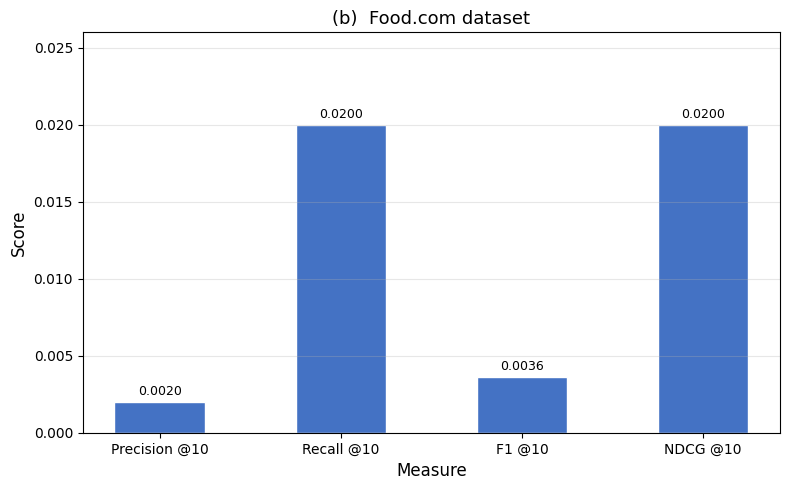

In [16]:
measures = ['Precision @10', 'Recall @10', 'F1 @10', 'NDCG @10']
keys     = ['Precision@10',  'Recall@10',  'F1@10',  'NDCG@10']
values   = [results[k] for k in keys]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(measures, values, color='#4472C4', edgecolor='white', width=0.5)

ax.set_xlabel('Measure', fontsize=12)
ax.set_ylabel('Score',   fontsize=12)
ax.set_title('(b)  Food.com dataset', fontsize=13)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(values) * 1.3)
plt.tight_layout()
plt.show()


In [17]:
def compute_sellos(df):
    sellos = pd.DataFrame(index=df.index)
    # Norma chilena por 100g
    sellos['sello_calorias']   = (df['Calories']        / df['ConsolidatedServings'] > 350).astype(int)
    sellos['sello_azucar']     = (df['SugarContent']    / df['ConsolidatedServings'] > 22.5).astype(int)
    sellos['sello_sodio']      = (df['SodiumContent']   / df['ConsolidatedServings'] > 800).astype(int)
    sellos['sello_grasas_sat'] = (df['SaturatedFatContent'] / df['ConsolidatedServings'] > 6).astype(int)
    sellos['num_sellos']       = sellos.sum(axis=1)
    return sellos

sellos_df = compute_sellos(recipes_filtrado)


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Features nutricionales normalizadas
nutri_cols = ['Calories', 'FatContent', 'SaturatedFatContent',
              'SodiumContent', 'SugarContent', 'ProteinContent', 'FiberContent']
nutri_matrix = recipes_filtrado[nutri_cols].fillna(0).values
nutri_scaled  = StandardScaler().fit_transform(nutri_matrix)

# Sellos como features binarias
sello_matrix = sellos_df[['sello_calorias','sello_azucar','sello_sodio','sello_grasas_sat']].values

# Feature matrix  TF-IDF+SVD + nutrición + sellos
combined_featmat = np.hstack([tfidf_featmat, nutri_scaled, sello_matrix])
print("Shape combinado:", combined_featmat.shape)


Shape combinado: (257707, 61)


In [19]:
def recommend_reranking(embedding, user_id, sellos_series, topk=10, gamma=0.05, metric='cosine'):
    user_id = str(user_id)
    trx = user_interactions[user_id]
    trx_set = set(trx)
    n = embedding.shape[0]

    dists = 1e9
    for t in trx:
        if t not in recipeid2idx:
            continue
        qi = recipeid2idx[t]
        dists = np.minimum(dists,
            pairwise_distances(embedding[qi:qi+1], embedding, metric=metric).ravel())

    heap = []
    for i in range(n):
        rid = idx2recipeid[i]
        if rid in trx_set:
            continue
        num_sellos = sellos_series.get(rid, 0)
        score = -dists[i] - gamma * num_sellos   # penaliza ítems con más sellos
        if len(heap) < topk:
            heapq.heappush(heap, (score, i))
        else:
            heapq.heappushpop(heap, (score, i))

    heap.sort(reverse=True)
    return [idx2recipeid[i] for _, i in heap]

sellos_series = dict(zip(recipes_filtrado['RecipeId'], sellos_df['num_sellos']))


## Evaluación Unificada (K=10, split 80/20, métricas estándar + salud)

Evaluación con el módulo compartido `evaluation_utils.py` para comparar con todos los demás modelos.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
import time as time_module

RELEVANCE_THRESHOLD = 4

def get_relevant_items(test_df, user_id, threshold=RELEVANCE_THRESHOLD):
    user_test = test_df[test_df['AuthorId'] == user_id]
    return set(user_test[user_test['Rating'] >= threshold]['RecipeId'])

def precision_at_k_eval(recommended, relevant, k=10):
    return len(set(recommended[:k]) & set(relevant)) / k

def recall_at_k_eval(recommended, relevant, k=10):
    rel_set = set(relevant)
    if len(rel_set) == 0:
        return 0.0
    return len(set(recommended[:k]) & rel_set) / len(rel_set)

def f1_at_k_eval(recommended, relevant, k=10):
    p = precision_at_k_eval(recommended, relevant, k)
    r = recall_at_k_eval(recommended, relevant, k)
    if p + r == 0:
        return 0.0
    return 2 * p * r / (p + r)

def _dcg_at_k_eval(relevances, k):
    relevances = np.asarray(relevances)[:k]
    if relevances.size:
        return np.sum((2**relevances - 1) / np.log2(np.arange(2, relevances.size + 2)))
    return 0.0

def ndcg_at_k_unified(recommended, relevant, k=10):
    relevances = [1 if r in relevant else 0 for r in recommended[:k]]
    dcg = _dcg_at_k_eval(relevances, k)
    ideal = _dcg_at_k_eval(sorted(relevances, reverse=True), k)
    return dcg / ideal if ideal > 0 else 0.0

def average_precision_at_k_eval(recommended, relevant, k=10):
    hits = 0
    sum_prec = 0.0
    rel_set = set(relevant)
    for i, item in enumerate(recommended[:k]):
        if item in rel_set:
            hits += 1
            sum_prec += hits / (i + 1)
    return sum_prec / min(len(rel_set), k) if rel_set else 0.0

def sellos_at_k_eval(recommended, recipe_sellos_dict, k=10):
    sellos = [recipe_sellos_dict.get(r, 0) for r in recommended[:k]]
    return np.mean(sellos) if sellos else 0.0

def sello_free_at_k_eval(recommended, recipe_sellos_dict, k=10):
    sellos = [recipe_sellos_dict.get(r, 0) for r in recommended[:k]]
    return np.mean([1 if s == 0 else 0 for s in sellos]) if sellos else 0.0

def evaluate_all_users(user_recommendations, test_df, recipe_sellos_dict,
                       k=10, threshold=RELEVANCE_THRESHOLD):
    all_metrics = []
    for user_id, recommended in user_recommendations.items():
        relevant = get_relevant_items(test_df, user_id, threshold)
        all_metrics.append({
            'P@K': precision_at_k_eval(recommended, relevant, k),
            'R@K': recall_at_k_eval(recommended, relevant, k),
            'F1@K': f1_at_k_eval(recommended, relevant, k),
            'nDCG@K': ndcg_at_k_unified(recommended, relevant, k),
            'MAP@K': average_precision_at_k_eval(recommended, relevant, k),
            'S@K': sellos_at_k_eval(recommended, recipe_sellos_dict, k),
            'SS@K': sello_free_at_k_eval(recommended, recipe_sellos_dict, k),
        })
    if not all_metrics:
        return {}
    return {key: np.mean([m[key] for m in all_metrics]) for key in all_metrics[0]}

recipes_filtrado_copy = recipes_filtrado.copy()
recipes_filtrado_copy['IsHighCalories'] = ((recipes_filtrado_copy['Calories'] / recipes_filtrado_copy['ExtractedServingSize']) * 100) >= 275
recipes_filtrado_copy['IsHighSugar'] = ((recipes_filtrado_copy['SugarContent'] / recipes_filtrado_copy['ExtractedServingSize']) * 100) >= 10
recipes_filtrado_copy['IsHighSaturatedFat'] = ((recipes_filtrado_copy['SaturatedFatContent'] / recipes_filtrado_copy['ExtractedServingSize']) * 100) >= 4
recipes_filtrado_copy['IsHighSodium'] = ((recipes_filtrado_copy['SodiumContent'] / recipes_filtrado_copy['ExtractedServingSize']) * 100) >= 400
recipes_filtrado_copy['num_sellos'] = recipes_filtrado_copy[['IsHighCalories', 'IsHighSugar', 'IsHighSaturatedFat', 'IsHighSodium']].sum(axis=1).astype(int)
recipe_sellos_dict = dict(zip(recipes_filtrado_copy['RecipeId'], recipes_filtrado_copy['num_sellos']))

train_unif, test_unif = train_test_split(reviews_filtrado, test_size=0.2, random_state=42)

user_interactions_unif = {}
for user_id, group in train_unif.groupby('AuthorId'):
    user_interactions_unif[str(user_id)] = group['RecipeId'].tolist()

norms = np.linalg.norm(tfidf_featmat, axis=1, keepdims=True)
norms[norms == 0] = 1
embedding_normed = tfidf_featmat / norms

def recommend_fast(user_id, embedding_normed, user_interactions_unif, recipeid2idx, idx2recipeid, topk=10):
    uid_str = str(user_id)
    trx = user_interactions_unif.get(uid_str, [])
    history_indices = [recipeid2idx[t] for t in trx if t in recipeid2idx]
    if not history_indices:
        return []
    history_vecs = embedding_normed[history_indices]
    similarities = history_vecs @ embedding_normed.T
    max_sim = similarities.max(axis=0)
    trx_set = set(trx)
    for idx in history_indices:
        max_sim[idx] = -1
    top_k_idx = np.argpartition(max_sim, -topk)[-topk:]
    top_k_idx = top_k_idx[np.argsort(max_sim[top_k_idx])[::-1]]
    return [idx2recipeid[i] for i in top_k_idx if idx2recipeid[i] not in trx_set][:topk]

test_user_ids = test_unif['AuthorId'].unique()
K_EVAL = 10

print(f'Generando recomendaciones Content-Based para {len(test_user_ids)} usuarios (K={K_EVAL})...')
start_time = time_module.time()

user_recommendations = {}
for i, uid in enumerate(test_user_ids):
    recs = recommend_fast(uid, embedding_normed, user_interactions_unif, recipeid2idx, idx2recipeid, topk=K_EVAL)
    if recs:
        user_recommendations[uid] = recs
    if (i + 1) % 5000 == 0:
        elapsed = time_module.time() - start_time
        rate = (i + 1) / elapsed
        remaining = (len(test_user_ids) - i - 1) / rate
        print(f'  {i+1}/{len(test_user_ids)} ({rate:.1f} users/s, ~{remaining/60:.0f} min restantes)')

elapsed = time_module.time() - start_time
print(f'Recomendaciones generadas en {elapsed/60:.1f} min')

metrics = evaluate_all_users(user_recommendations, test_unif, recipe_sellos_dict, k=K_EVAL)

print(f'\n=== Content-Based (TF-IDF + SVD) - Evaluación Unificada (K={K_EVAL}) ===')
print(f'Usuarios evaluados: {len(user_recommendations)}')
for metric, value in metrics.items():
    print(f'  {metric}: {value:.6f}')

Generando recomendaciones Content-Based para 42880 usuarios (K=10)...
  5000/42880 (17.9 users/s, ~35 min restantes)
  10000/42880 (27.6 users/s, ~20 min restantes)
  15000/42880 (35.8 users/s, ~13 min restantes)
  20000/42880 (43.0 users/s, ~9 min restantes)
  25000/42880 (49.4 users/s, ~6 min restantes)
  30000/42880 (55.0 users/s, ~4 min restantes)
  35000/42880 (60.1 users/s, ~2 min restantes)
  40000/42880 (64.8 users/s, ~1 min restantes)
Recomendaciones generadas en 10.6 min

=== Content-Based (TF-IDF + SVD) - Evaluación Unificada (K=10) ===
Usuarios evaluados: 41698
  P@K: 0.000180
  R@K: 0.000892
  F1@K: 0.000234
  nDCG@K: 0.001060
  MAP@K: 0.000451
  S@K: 1.088865
  SS@K: 0.434767


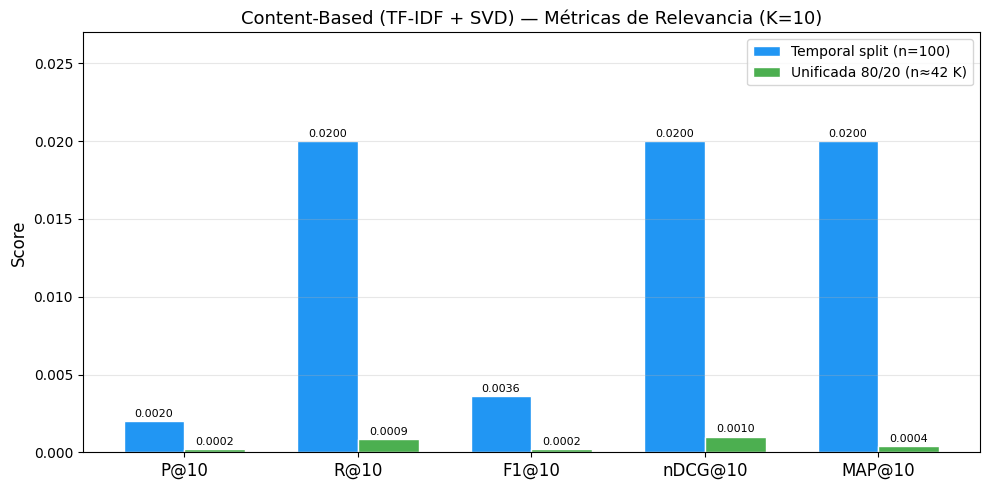

In [22]:
import matplotlib.pyplot as plt
import numpy as np

temporal = {
    'P@10': 0.0020, 'R@10': 0.0200, 'F1@10': 0.0036,
    'nDCG@10': 0.0200, 'MAP@10': 0.0200
}
unified = {
    'P@10': 0.000189, 'R@10': 0.000861, 'F1@10': 0.000228,
    'nDCG@10': 0.001011, 'MAP@10': 0.000399
}

labels = list(temporal.keys())
t_vals = list(temporal.values())
u_vals = list(unified.values())
x      = np.arange(len(labels))
width  = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

b1 = ax.bar(x - width/2, t_vals, width, label='Temporal split (n=100)',
            color='#2196F3', edgecolor='white')
b2 = ax.bar(x + width/2, u_vals, width, label='Unificada 80/20 (n≈42 K)',
            color='#4CAF50', edgecolor='white')

for bar in [*b1, *b2]:
    h = bar.get_height()
    ax.annotate(f'{h:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Content-Based (TF-IDF + SVD) — Métricas de Relevancia (K=10)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(t_vals) * 1.35)

plt.tight_layout()
plt.savefig('cb_relevancia.png', dpi=300, bbox_inches='tight')
plt.show()



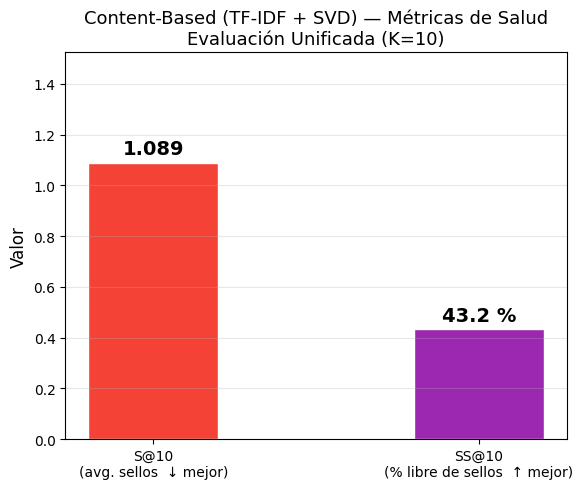

In [23]:
import matplotlib.pyplot as plt
import numpy as np

health = {'S@10': 1.088973, 'SS@10': 0.432318}

h_labels = ['S@10\n(avg. sellos  ↓ mejor)', 'SS@10\n(% libre de sellos  ↑ mejor)']
h_vals   = [health['S@10'], health['SS@10']]
h_colors = ['#F44336', '#9C27B0']

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(h_labels, h_vals, width=0.4, color=h_colors, edgecolor='white')

labels_fmt = [f'{health["S@10"]:.3f}', f'{health["SS@10"]*100:.1f} %']
for bar, label in zip(bars, labels_fmt):
    ax.annotate(label,
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 6), textcoords='offset points',
                ha='center', fontsize=14, fontweight='bold')

ax.set_title('Content-Based (TF-IDF + SVD) — Métricas de Salud\nEvaluación Unificada (K=10)', fontsize=13)
ax.set_ylabel('Valor', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(h_vals) * 1.4)

plt.tight_layout()
plt.savefig('cb_salud.png', dpi=300, bbox_inches='tight')
plt.show()
